In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
import pandahouse as ph

In [2]:
connection = {
    'host': 'https://clickhouse.lab.karpov.courses',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

In [8]:
q = """
SELECT
    post_id,
    time,
    action
FROM simulator_20250520.feed_actions
LIMIT 10000
"""
feed_actions = ph.read_clickhouse(query=q, connection=connection)

In [9]:
feed_actions['time'] = pd.to_datetime(feed_actions['time'])
print(feed_actions.head())

   post_id                time action
0     3390 2025-05-20 20:46:50   view
1     3324 2025-05-20 20:46:50   like
2     3389 2025-05-20 20:46:50   view
3     3279 2025-05-20 20:46:51   view
4     3359 2025-05-20 20:46:51   view


In [10]:
post_metrics = feed_actions.groupby('post_id').agg(
    min_time=('time', 'min'),
    max_time=('time', 'max'),
    likes=('action', lambda x: (x == 'like').sum()),
    views=('action', lambda x: (x == 'view').sum())
).reset_index()

# Рассчитываем время жизни поста в днях
post_metrics['lifetime_days'] = (post_metrics['max_time'] - post_metrics['min_time']).dt.total_seconds() / (24 * 3600)

# Рассчитываем CTR, избегая деления на ноль
post_metrics['CTR'] = post_metrics['likes'] / post_metrics['views']
post_metrics['CTR'] = post_metrics['CTR'].fillna(0)

final_df = post_metrics[['post_id', 'CTR', 'lifetime_days', 'views', 'likes']]

print("\nРассчитанные метрики:")
print(final_df.head())


Рассчитанные метрики:
   post_id       CTR  lifetime_days  views  likes
0     2856  0.166667       0.005544      6      1
1     2867  0.100000       0.005938     10      1
2     2871  0.230769       0.004954     13      3
3     2936  0.178571       0.006100     56     10
4     2947  0.131579       0.005926     38      5


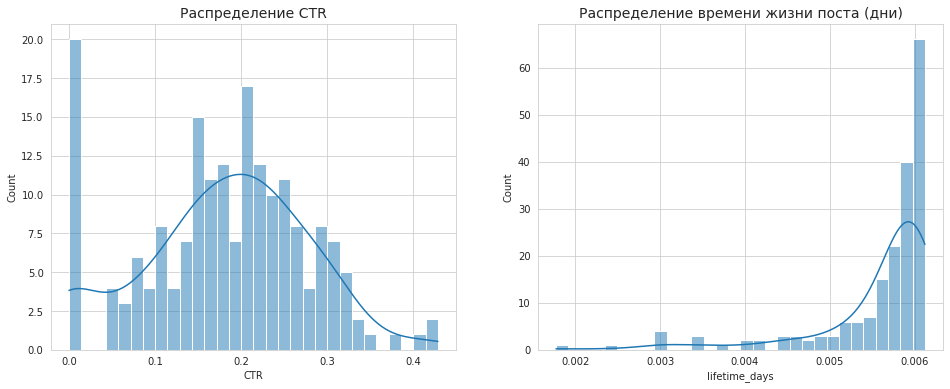

In [11]:
sns.set_style('whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(final_df['CTR'], bins=30, kde=True, ax=ax1)
ax1.set_title('Распределение CTR', fontsize=14)

sns.histplot(final_df['lifetime_days'], bins=30, kde=True, ax=ax2)
ax2.set_title('Распределение времени жизни поста (дни)', fontsize=14)
plt.show()

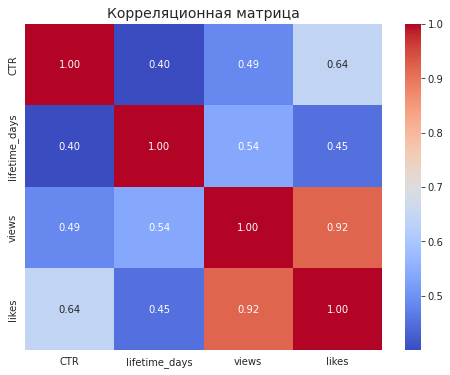

In [12]:
corr_matrix = final_df[['CTR', 'lifetime_days', 'views', 'likes']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица', fontsize=14)
plt.show()

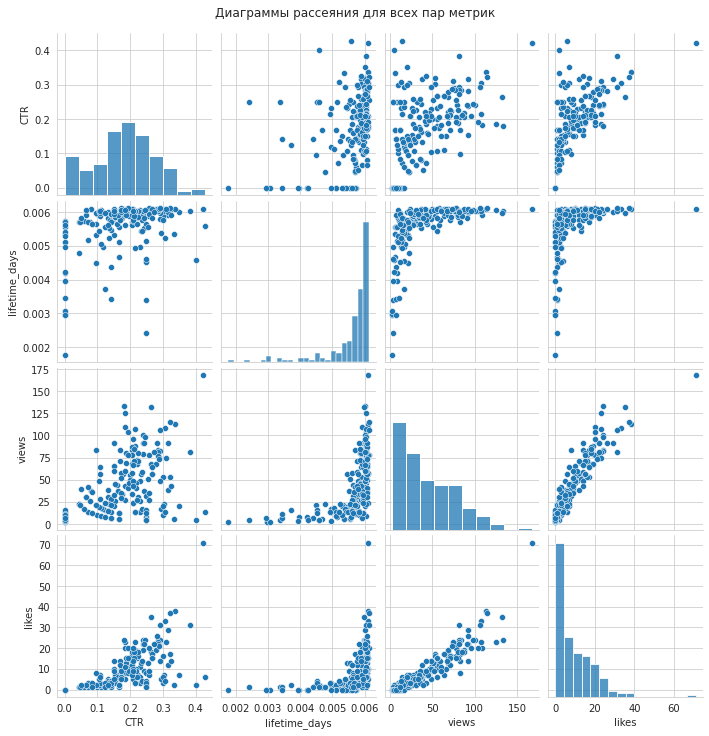

In [13]:
sns.pairplot(final_df[['CTR', 'lifetime_days', 'views', 'likes']])
plt.suptitle('Диаграммы рассеяния для всех пар метрик', y=1.02)
plt.show()

In [14]:
mean_lifetime = final_df['lifetime_days'].mean()
print(f"\nСреднее время жизни поста: {mean_lifetime:.2f} дней")


Среднее время жизни поста: 0.01 дней
